 ## PROJECT

The goal of this project is to analyze what factors influence happiness scores across countries and to build a model to predict happiness levels.


In [8]:
import pandas as pd


In [10]:
df = pd.read_csv("world_happiness_report_2005_2025.csv")
df.head()

,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
0,2011,1,Denmark,7.856,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011,2,Finland,7.579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011,3,Norway,7.524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2011,4,Netherlands,7.512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2011,5,Canada,7.499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.to_csv("raw_happiness_data.csv", index=False)


In [14]:
# To reload data later:
# df = pd.read_csv("raw_happiness_data.csv")


In [16]:
print(df.shape)

(2116, 13)


In [18]:
print(df.columns)


Index(['year', 'rank_in_year', 'country', 'happiness_score', 'lower_whisker',
       'upper_whisker', 'explained_log_gdp_per_capita',
       'explained_social_support', 'explained_healthy_life_expectancy',
       'explained_freedom', 'explained_generosity', 'explained_corruption',
       'dystopia_plus_residual'],
      dtype='object')


In [20]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   year                               2116 non-null   int64  
 1   rank_in_year                       2116 non-null   int64  
 2   country                            2116 non-null   object 
 3   happiness_score                    2116 non-null   float64
 4   lower_whisker                      1022 non-null   float64
 5   upper_whisker                      1022 non-null   float64
 6   explained_log_gdp_per_capita       1019 non-null   float64
 7   explained_social_support           1019 non-null   float64
 8   explained_healthy_life_expectancy  1016 non-null   float64
 9   explained_freedom                  1017 non-null   float64
 10  explained_generosity               1019 non-null   float64
 11  explained_corruption               1018 non-null   float

In [22]:
df.describe()

,year,rank_in_year,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
count,2116.000000,2116.000000,2116.000000,1022.000000,1022.000000,1019.000000,1019.000000,1016.000000,1017.000000,1019.000000,1018.000000,1013.000000
mean,2018.220227,76.190926,5.465655,5.436091,5.664733,1.265670,1.096746,0.553435,0.609465,0.147343,0.144911,1.736935
std,4.249844,43.845101,1.123870,1.140959,1.107424,0.463823,0.357642,0.229980,0.212070,0.084335,0.118803,0.657497
min,2011.000000,1.000000,1.364000,1.301000,1.427000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.295000
25%,2015.000000,38.000000,4.604750,4.619707,4.867750,0.944000,0.865000,0.389750,0.471000,0.088000,0.063156,1.305000
50%,2018.000000,76.000000,5.480000,5.592631,5.812000,1.304000,1.140119,0.560500,0.602000,0.134000,0.113000,1.765000
75%,2022.000000,114.000000,6.321250,6.290110,6.486500,1.636000,1.382000,0.712325,0.735000,0.195477,0.181330,2.178000
max,2025.000000,158.000000,7.856000,7.780000,7.904000,2.209000,1.840000,1.238000,1.147000,0.569814,0.587000,3.482000


In [24]:
df.isnull().sum()

year                                    0
rank_in_year                            0
country                                 0
happiness_score                         0
lower_whisker                        1094
upper_whisker                        1094
explained_log_gdp_per_capita         1097
explained_social_support             1097
explained_healthy_life_expectancy    1100
explained_freedom                    1099
explained_generosity                 1097
explained_corruption                 1098
dystopia_plus_residual               1103
dtype: int64

### Exploratory Data Analysis

The dataset contains multiple variables related to happiness across countries, including economic factors (GDP), social support, and health.

Initial exploration shows that the dataset contains missing values, particularly in some explanatory variables. This indicates that data cleaning will be necessary before applying machine learning models.

The target variable in this project is the happiness score.

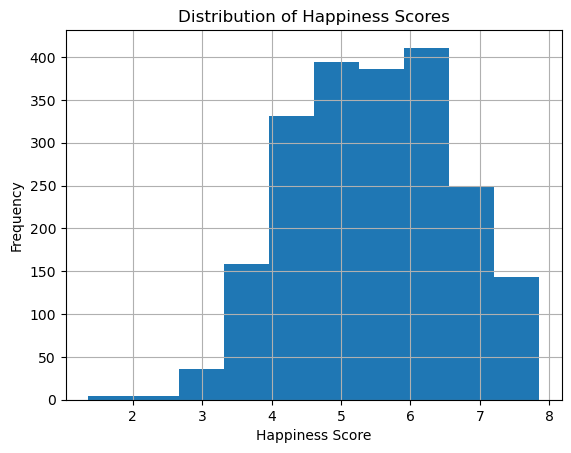

In [29]:
import matplotlib.pyplot as plt

df["happiness_score"].hist()
plt.title("Distribution of Happiness Scores")
plt.xlabel("Happiness Score")
plt.ylabel("Frequency")
plt.show()


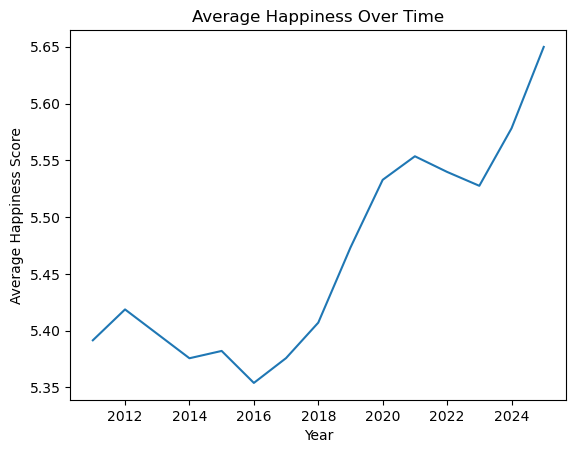

In [31]:
df.groupby("year")["happiness_score"].mean().plot()
plt.title("Average Happiness Over Time")
plt.xlabel("Year")
plt.ylabel("Average Happiness Score")
plt.show()

In [33]:
df.isnull().sum().sort_values(ascending=False)


dystopia_plus_residual               1103
explained_healthy_life_expectancy    1100
explained_freedom                    1099
explained_corruption                 1098
explained_log_gdp_per_capita         1097
explained_social_support             1097
explained_generosity                 1097
lower_whisker                        1094
upper_whisker                        1094
year                                    0
rank_in_year                            0
country                                 0
happiness_score                         0
dtype: int64

In [35]:
df_clean = df.dropna(axis=1, thresh=len(df)*0.7)


In [37]:
df_clean = df_clean.dropna()


In [39]:
df_clean.isnull().sum()

year               0
rank_in_year       0
country            0
happiness_score    0
dtype: int64

In [41]:
df_clean = df_clean.drop(["country", "rank_in_year"], axis=1)

In [43]:
X = df_clean.drop("happiness_score", axis=1)
y = df_clean["happiness_score"]

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### Data Cleaning and Transformation

The dataset contained several missing values, particularly in some explanatory variables. To address this, columns with too many missing values were removed, and remaining rows with missing values were dropped.

Irrelevant columns such as country names and ranking were removed, as they are not useful for predicting happiness scores.

The dataset was then split into input features (X) and the target variable (y), which is the happiness score.

Finally, the data was scaled using StandardScaler to ensure that all variables are on a comparable scale, which improves the performance of machine learning models.
``

In [50]:
import matplotlib.pyplot as plt

correlation = df_clean.corr()

print(correlation["happiness_score"].sort_values(ascending=False))

happiness_score    1.00000
year               0.06959
Name: happiness_score, dtype: float64


In [54]:
df2 = pd.read_csv("world_happiness_report_2005_2025.csv")


In [56]:
columns_to_keep = [
    "year",
    "happiness_score",
    "explained_log_gdp_per_capita",
    "explained_social_support",
    "explained_healthy_life_expectancy"
]

df2 = df2[columns_to_keep]

In [58]:
df2 = df2.dropna()


In [60]:
X = df2.drop("happiness_score", axis=1)
y = df2["happiness_score"]

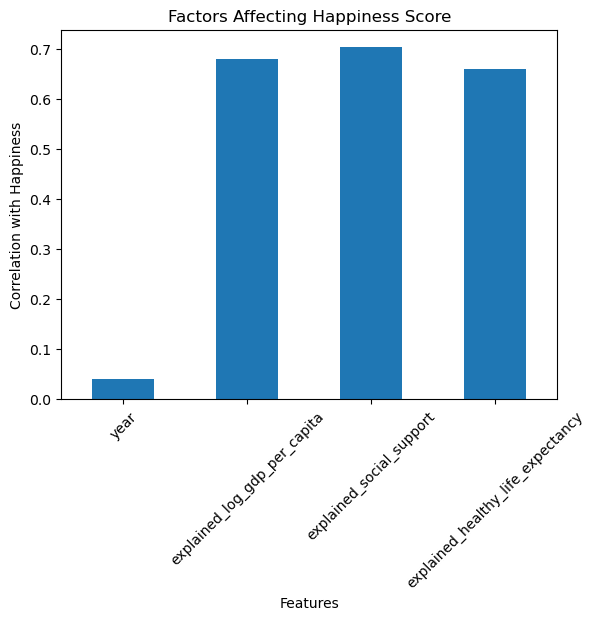

In [62]:
corr = df2.corr()

corr["happiness_score"].drop("happiness_score").plot(kind="bar")

plt.title("Factors Affecting Happiness Score")
plt.xlabel("Features")
plt.ylabel("Correlation with Happiness")
plt.xticks(rotation=45)
plt.show()


After selecting key explanatory variables manually, the analysis shows that GDP, social support, and health are strongly correlated with happiness scores, while time (year) has a weaker effect.

In [65]:
import requests

def explain_feature(feature_name):
    prompt = f"""
Explain in 2-3 sentences how {feature_name} affects happiness in a country.
Keep the answer concise.
"""

    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": "gemma3:270m",
            "prompt": prompt,
            "stream": False
        }
    )

    return response.json()["response"]

In [67]:
features = [
    "GDP per capita",
    "social support",
    "healthy life expectancy"
]

for f in features:
    print(f"\nExplanation for {f}:")
    print(explain_feature(f))



Explanation for GDP per capita:
GDP per capita measures a country's wealth and income, which can influence happiness levels by factors like standard of living, access to healthcare, education, and social welfare programs.


Explanation for social support:
Social support provides a vital buffer against stress and negative emotions, fostering a sense of well-being and increasing happiness. It allows individuals to cope with challenges and build resilience in the face of adversity.


Explanation for healthy life expectancy:
Healthy life expectancy significantly impacts happiness, as it allows individuals to maintain a good quality of life and experience a greater sense of well-being. This translates to improved mental health, reduced stress, and increased opportunities for social connection and personal fulfillment.



### API / LLM Integration

In this project, a local language model (gemma3 via Ollama) was used to provide explanations for the key factors influencing happiness.

The model was prompted to explain how variables such as GDP per capita, social support, and life expectancy affect happiness levels.

This demonstrates how large language models can be used alongside traditional data analysis to provide additional insights and interpretations.

In [72]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


In [74]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_pred
})

results.to_csv("happiness_predictions.csv", index=False)

results.head()


,Actual,Predicted
1618,5.466,5.493409
1471,5.533,5.506879
259,4.826,5.469332
432,4.514,5.392029
1506,4.872,5.506879


### Data Pipeline

![Data Pipeline](pipeline.png)



## Conclusion

This project analyzed the factors influencing happiness across countries using data from the World Happiness Report.

The analysis showed that GDP per capita, social support, and healthy life expectancy are the most important factors affecting happiness.

Machine learning models were used to predict happiness scores, and the Random Forest model performed the best due to its ability to capture complex relationships in the data.

Additionally, a language model was used to provide explanations for the importance of these variables, demonstrating how AI can complement traditional data analysis.

Overall, the results show that happiness can be reasonably predicted using economic and social variables, although there are additional factors that may not be captured in the dataset.


### Statement of AI Use

AI (ChatGPT) was used to assist with debugging, structuring the notebook, and explaining concepts.